In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
# Paths based on your Kaggle dataset structure
train_dir = "/kaggle/input/cardiomegaly-disease-prediction-using-cnn/train/train"
test_dir = "/kaggle/input/cardiomegaly-disease-prediction-using-cnn/test/test"

img_size = 224
batch_size = 32


In [4]:
# Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load train/val data
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Load test data
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 3552 images belonging to 2 classes.
Found 886 images belonging to 2 classes.
Found 1114 images belonging to 2 classes.


In [6]:
model = Sequential([
    Conv2D(128, (3,3), activation='relu', padding='same', input_shape=(img_size, img_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(optimizer=Adamax(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    51,380,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,272,386 (199.40 MB)

 Trainable params: 52,271,106 (199.40 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [17]:
# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    verbose=1
)


Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 49s 440ms/step - accuracy: 0.6104 - loss: 0.6627 - val_accuracy: 0.6264 - val_loss: 0.6446
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 49s 438ms/step - accuracy: 0.5905 - loss: 0.6600 - val_accuracy: 0.6230 - val_loss: 0.6485
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 432ms/step - accuracy: 0.6010 - loss: 0.6636 - val_accuracy: 0.6106 - val_loss: 0.7020
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 430ms/step - accuracy: 0.5837 - loss: 0.6756 - val_accuracy: 0.6298 - val_loss: 0.6455
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 49s 438ms/step - accuracy: 0.5963 - loss: 0.6593 - val_accuracy: 0.6287 - val_loss: 0.6545
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 47s 426ms/step - accuracy: 0.6082 - loss: 0.6520 - val_accuracy: 0.6230 - val_loss: 0.6498
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 49s 439ms/step - accuracy: 0.5938 - loss: 0.6637 - val_accuracy: 0.6230 - val_loss: 0.6609
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 429ms/step - accuracy: 0.5962 - loss: 0

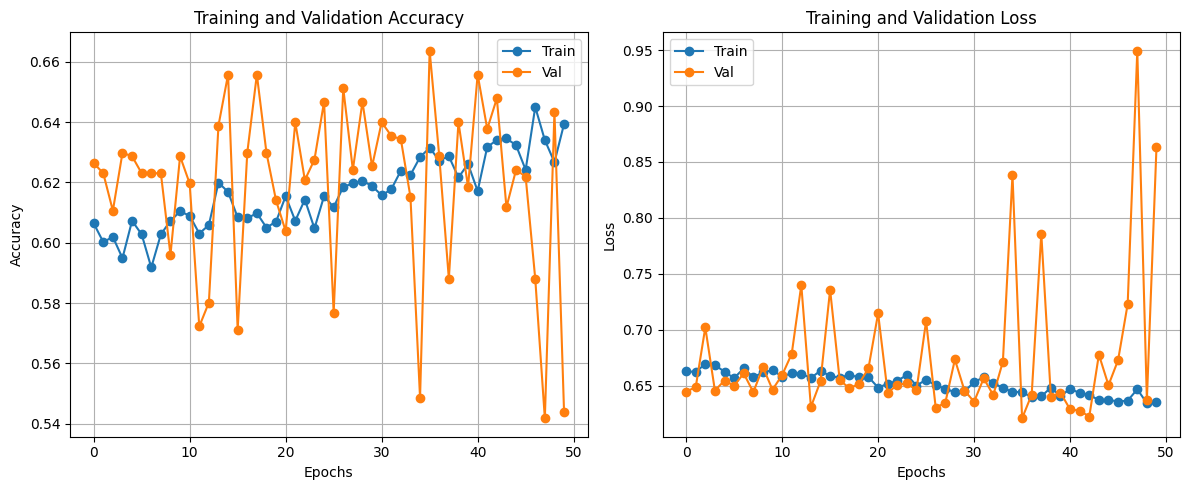

In [18]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train', marker='o')
plt.plot(history.history['val_accuracy'], label='Val', marker='o')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.grid(True); plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train', marker='o')
plt.plot(history.history['val_loss'], label='Val', marker='o')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()


In [21]:
# Evaluate test accuracy
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n Final Test Accuracy: {test_acc * 100:.2f}%")


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7943 - loss: 0.4956

 Final Test Accuracy: 55.12%


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step


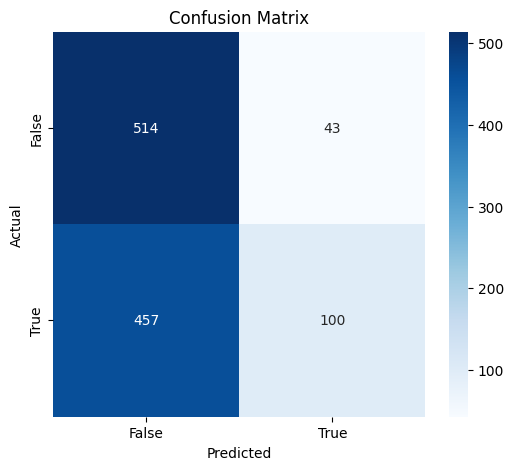

Classification Report:

              precision    recall  f1-score   support

       False       0.53      0.92      0.67       557
        True       0.70      0.18      0.29       557

    accuracy                           0.55      1114
   macro avg       0.61      0.55      0.48      1114
weighted avg       0.61      0.55      0.48      1114



In [22]:
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=['False', 'True']))


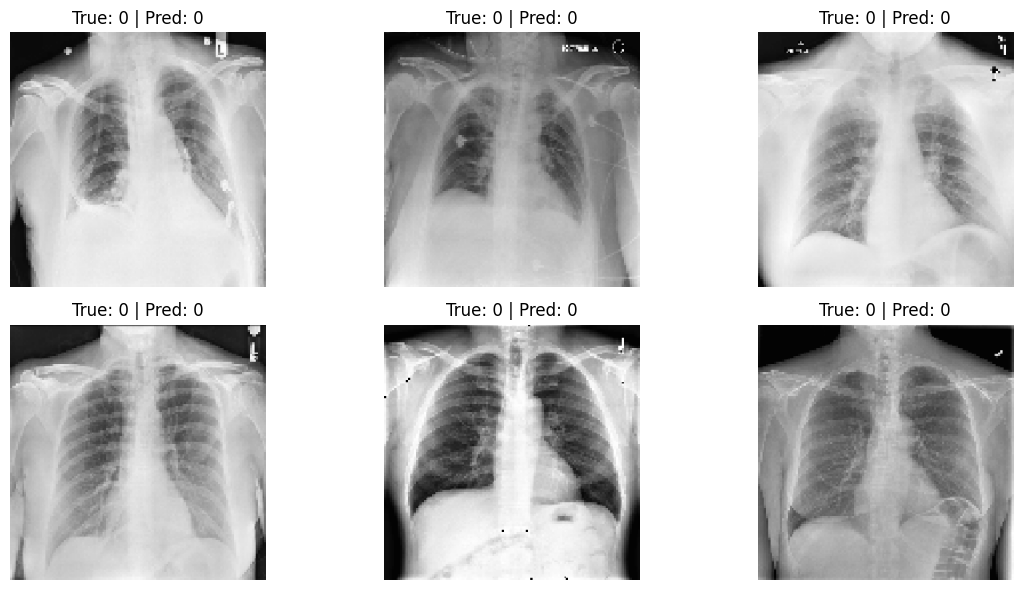

In [23]:
# random predictions visualization
import random

X, y = next(test_gen)  # FIXED: replaced .next() with built-in next()

plt.figure(figsize=(12, 6))
for i in range(6):
    img = X[i]
    true = np.argmax(y[i])
    pred = np.argmax(model.predict(np.expand_dims(img, axis=0), verbose=0))

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"True: {true} | Pred: {pred}")
    plt.axis('off')

plt.tight_layout()
plt.show()

